In [ ]:
import pandas as pd
import os

# folder with individual .csv datafiles
master_data_path = "data"

# output csv file name
output_csv_path = "koh_master.csv"

# dataframe for the merged data
koh_data = pd.DataFrame()

# iterate over files in dir
for filename in os.listdir(master_data_path):
    if filename.endswith(".csv"):
        # read csv to dataframe
        df = pd.read_csv(os.path.join(master_data_path, filename))
        # concatenate df to merged df
        koh_data = pd.concat([koh_data, df], ignore_index = True)

# save merged df to csv
koh_data.to_csv(output_csv_path, index = False)

In [16]:
import numpy as np

data = pd.read_csv("koh_master.csv")

conditions = [
    (data["Outline"] == "target") & (data["trial type"] == True) & (data["Target Spread"] == True),
    (data["Outline"] == "target") & (data["trial type"] == True) & (data["Target Spread"] == False),
    (data["Outline"] == "target") & (data["trial type"] == False) & (data["Target Spread"] == True),
    (data["Outline"] == "target") & (data["trial type"] == False) & (data["Target Spread"] == False),
    (data["Outline"] == "catch") & (data["trial type"] == True) & (data["Target Spread"] == True),
    (data["Outline"] == "catch") & (data["trial type"] == True) & (data["Target Spread"] == False),
    (data["Outline"] == "catch") & (data["trial type"] == False) & (data["Target Spread"] == True),
    (data["Outline"] == "catch") & (data["trial type"] == False) & (data["Target Spread"] == False),
]
choices = ['target-outlined-spread', 'target-outlined-joined', 'target-notoutlined-spread', 'target-notoutlined-joined',
           'caatch-outlined-spread', 'catch-outlined-joined', 'catch-notoutlined-spread', 'catch-notoutlined-joined']

choices2 = ['TOS', 'TOJ', 'TNS', 'TNJ', 'COS', 'COJ', 'CNS', 'CNJ']

data['trial_type'] = np.select(conditions, choices2, default='n/a')
data.to_csv("koh_master.csv", index = False)

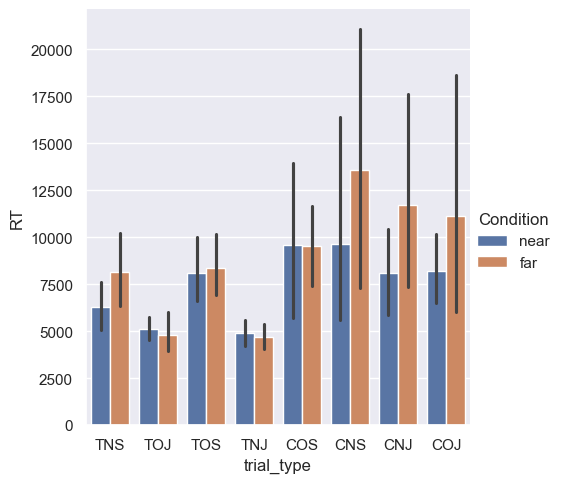

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

data = pd.read_csv("koh_master.csv")

bar = sns.catplot(
    data=data[data["Response Accuracy"] == 1], 
    kind = "bar",
    x="trial_type", 
    y="RT",
    hue="Condition"#,
    #row = "Subject ID"
    )

plt.show()